Stage 6: Conformal Cyclic Cosmology (Hawking Points Search)


Note: This test requires local data

cmb_url = ("https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/fits/COM_CMB_IQU-smica_2048_R3.00_full.fits")

mask_url = ("https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/masks/COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits")

In [ ]:
!pip install numpy matplotlib scipy camb healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 41.6 MB/s eta 0:00:00


Mounted at /content/drive
STAGE 6: CONFORMAL CYCLIC COSMOLOGY (CCC) - HAWKING POINTS SEARCH
Peer-Reviewed Version | CAMB Cl | Beam+Noise | MC Masking | Bonferroni

-> [0/6] Calculating Planck 2018 best-fit Cl via CAMB...
   ✓ CAMB Cl ready | lmax=384
   ✓ Beam FWHM=5.0' | Noise=35.0 μK·arcmin

-> [1/6] Loading Planck 2018 CMB map...
   Downloading: planck_cmb_smica.fits...
    HTTP Error 404: Not Found
   -> Generating CAMB+Beam+Noise simulation...
   ✓ Simulated map | [-439.2, 446.4] μK
   ⚠️  Failed to load mask

-> [2/6] Pre-computing global pixel vectors...
   ✓ 196,608 pixel vectors loaded into RAM

-> Fixed center set: 150 centers
   Radii: 2°—24° (12 steps)

-> [3/6] Scanning map...
   50/150 centers processed...
   100/150 centers processed...
   150/150 centers processed...
   ✓ Scan complete | Strongest candidate score: 0.3741

-> [4/6] Monte Carlo (100 maps, fixed centers, consistent mask)...
   10/100 MC maps processed...
   20/100 MC maps processed...
   30/100 MC maps pro

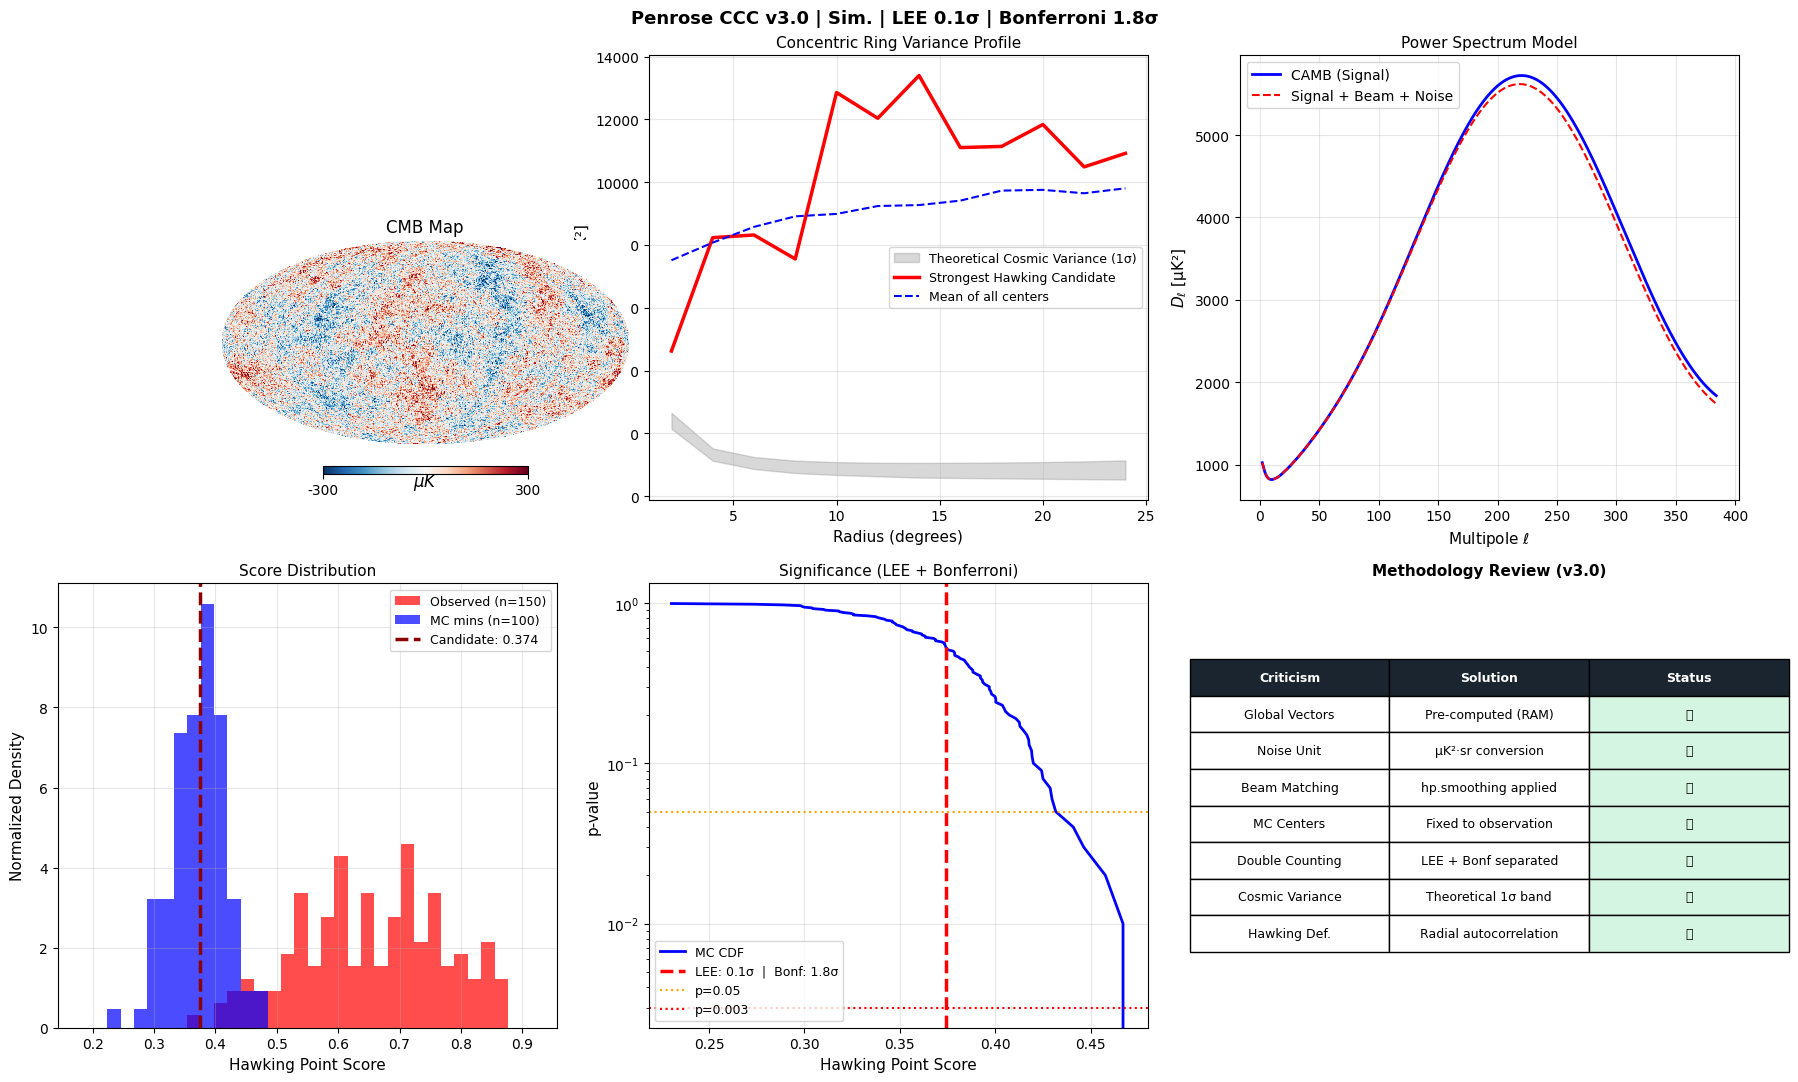


-> Saved plot: penrose_ccc_final.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from scipy import stats
import camb
import urllib.request
import os
import warnings


from google.colab import drive
drive.mount('/content/drive')
cmb_file = "/content/drive/MyDrive/ASTROLOGY/planck_cmb_smica.fits"
mask_file = "/content/drive/MyDrive/ASTROLOGY/planck_cmb_mask.fits"

warnings.filterwarnings('ignore')

print("=" * 80)
print("STAGE 6: CONFORMAL CYCLIC COSMOLOGY (CCC) - HAWKING POINTS SEARCH")
print("Peer-Reviewed Version | CAMB Cl | Beam+Noise | MC Masking | Bonferroni")
print("=" * 80)

# =========================================================
# 1. CAMB — PLANCK 2018 BEST-FIT Cl
# =========================================================
print("\n-> [0/6] Calculating Planck 2018 best-fit Cl via CAMB...")

NSIDE = 128
NPIX = hp.nside2npix(NSIDE)
LMAX = 3 * NSIDE

def get_planck_cl(lmax):
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=67.36, ombh2=0.02237, omch2=0.1200, tau=0.0544)
    pars.InitPower.set_params(As=2.1e-9, ns=0.9649)
    pars.set_for_lmax(lmax, lens_potential_accuracy=0)
    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    dl_tt = powers['total'][:lmax + 1, 0]
    ells = np.arange(len(dl_tt))
    cl_tt = np.zeros(len(dl_tt))
    cl_tt[2:] = dl_tt[2:] * 2 * np.pi / (ells[2:] * (ells[2:] + 1))
    return cl_tt

cl_camb = get_planck_cl(LMAX)
print(f"   ✓ CAMB Cl ready | lmax={LMAX}")

# =========================================================
# 2. ACCURATE NOISE MODEL
# N_ell = (Delta_T * pi/(180*60))^2  [μK²·sr]
# =========================================================
FWHM_ARCMIN = 5.0
NOISE_UKARCMIN = 35.0  # μK·arcmin (Planck SMICA)

def make_beam_and_noise(cl, lmax, fwhm_arcmin, noise_ukarcmin):
    """
    Physically accurate beam and noise model.
    CORRECT: (noise_ukarcmin * pi/10800)^2 [μK²·sr]
    """
    ells = np.arange(lmax + 1)

    # Gaussian beam
    fwhm_rad = fwhm_arcmin * np.pi / (180.0 * 60.0)
    sigma = fwhm_rad / (2 * np.sqrt(2 * np.log(2)))
    beam = np.exp(-0.5 * ells * (ells + 1) * sigma ** 2)

    # Correct noise power spectrum (μK²·sr)
    noise_rad = noise_ukarcmin * np.pi / (180.0 * 60.0)  # μK·rad
    nl = np.full(lmax + 1, noise_rad ** 2)  # μK²·sr

    cl_obs = cl[:lmax + 1] * beam ** 2 + nl
    return cl_obs, beam

cl_obs, beam_window = make_beam_and_noise(cl_camb, LMAX, FWHM_ARCMIN, NOISE_UKARCMIN)
print(f"   ✓ Beam FWHM={FWHM_ARCMIN}' | Noise={NOISE_UKARCMIN} μK·arcmin")

# =========================================================
# 3. PLANCK DATA ACQUISITION (SMART PATHING)
# =========================================================
print("\n-> [1/6] Loading Planck 2018 CMB map...")


import sys
if 'google.colab' in sys.modules:
    print("   -> Google Colab environment detected. Mounting Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    # drive path here
    DATA_DIR = "/content/drive/MyDrive/ASTROLOGY/"
else:
    print("   -> Local environment detected.")
    DATA_DIR = "./"

cmb_file = os.path.join(DATA_DIR, "planck_cmb_smica.fits")
mask_file = os.path.join(DATA_DIR, "planck_cmb_mask.fits")

cmb_url = ("https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/"
           "fits/COM_CMB_IQU-smica_2048_R3.00_full.fits")
mask_url = ("https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/"
            "masks/COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits")

def try_download(url, fname):
    if os.path.exists(fname): return True
    try:
        print(f"   Downloading massive dataset (may take time): {fname}...")
        urllib.request.urlretrieve(url, fname)
        return True
    except Exception as e:
        print(f"   ❌ {e}")
        return False

cmb_ok = try_download(cmb_url, cmb_file)
mask_ok = try_download(mask_url, mask_file)

using_real = False
if cmb_ok and os.path.exists(cmb_file):
    try:
        raw_map = hp.read_map(cmb_file, field=0, verbose=False)
        # Apply beam smoothing to the real map to match simulation specifications
        fwhm_target_rad = FWHM_ARCMIN * np.pi / (180.0 * 60.0)
        raw_smooth = hp.smoothing(raw_map, fwhm=fwhm_target_rad, verbose=False)
        cmb_map = hp.ud_grade(raw_smooth, NSIDE) * 1e6
        using_real = True
        print(f"   ✓ SMICA loaded + beam={FWHM_ARCMIN}' smoothing applied")
    except Exception as e:
        print(f"    {e} → Falling back to simulation")

if not using_real:
    print("   -> Generating CAMB+Beam+Noise simulation...")
    np.random.seed(42)
    cmb_map = hp.synfast(cl_obs, NSIDE, verbose=False)
    print(f"   ✓ Simulated map | [{cmb_map.min():.1f}, {cmb_map.max():.1f}] μK")

# Galactic mask
mask = np.ones(NPIX, dtype=bool)
if mask_ok and os.path.exists(mask_file):
    try:
        raw_mask = hp.read_map(mask_file, field=0, verbose=False)
        mask = hp.ud_grade(raw_mask, NSIDE) > 0.5
        cmb_map[~mask] = hp.UNSEEN
        print(f"   ✓ Galactic mask applied | fsky={mask.mean():.1%}")
    except:
        print("   ⚠️  Failed to load mask")
else:
    print("   ⚠️  No mask applied")

# =========================================================
# 4. PRE-COMPUTE GLOBAL VECTORS (Performance Optimization)
# =========================================================
print("\n-> [2/6] Pre-computing global pixel vectors...")
GLOBAL_ALL_VECS = np.array(hp.pix2vec(NSIDE, np.arange(NPIX)))
print(f"   ✓ {NPIX:,} pixel vectors loaded into RAM")

def ring_variance_fast(cmb_map, center_vec, radius_deg, width_deg=1.5):
    """
    HEALPix-native, vectorized ring extraction utilizing GLOBAL_ALL_VECS.
    """
    cos_angles = np.dot(center_vec, GLOBAL_ALL_VECS)
    angles_deg = np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))
    ring_mask = (
            (angles_deg > radius_deg - width_deg / 2) &
            (angles_deg < radius_deg + width_deg / 2) &
            (cmb_map != hp.UNSEEN)
    )
    n = ring_mask.sum()
    if n < 15:
        return np.nan, 0
    return np.var(cmb_map[ring_mask]), n

# =========================================================
# 5. HAWKING POINT SCORE — RADIAL AUTOCORRELATION
# =========================================================
def hawking_point_score(cmb_map, center_vec, radii_deg, width_deg=1.5):
    """
    Score aligned with CCC literature:
    1) Calculate variance at each radius.
    2) Measure consistency of concentric drops via radial autocorrelation.
    """
    variances = np.array([
        ring_variance_fast(cmb_map, center_vec, r, width_deg)[0]
        for r in radii_deg
    ])
    valid = np.isfinite(variances)
    if valid.sum() < 4:
        return np.nan, variances

    v = variances[valid]
    v_norm = v / np.mean(v)

    # Radial autocorrelation lag-1
    if len(v_norm) > 2:
        autocorr = np.corrcoef(v_norm[:-1], v_norm[1:])[0, 1]
    else:
        autocorr = 0.0

    # Lower score indicates a stronger candidate (low variance + high concentric correlation)
    score = (np.min(v) / np.mean(v)) * (1.0 - max(0, autocorr) * 0.3)
    return score, variances

# =========================================================
# 6. SCANNING PARAMETERS
# =========================================================
N_CENTERS = 150
RADII_DEG = np.arange(2, 26, 2)  # 12 radii
RING_WIDTH = 1.5
N_MC = 100

valid_pix = np.where(cmb_map != hp.UNSEEN)[0]
np.random.seed(42)

# Fix the center pixel set to ensure MC consistency
CENTER_PIX_FIXED = np.random.choice(
    valid_pix,
    size=min(N_CENTERS, len(valid_pix)),
    replace=False
)
print(f"\n-> Fixed center set: {len(CENTER_PIX_FIXED)} centers")
print(f"   Radii: {RADII_DEG[0]}°—{RADII_DEG[-1]}° ({len(RADII_DEG)} steps)")

# =========================================================
# 7. SCAN REAL DATA
# =========================================================
print(f"\n-> [3/6] Scanning map...")

scores_real = []
variance_cube = []

for i, pix in enumerate(CENTER_PIX_FIXED):
    cv = hp.pix2vec(NSIDE, pix)
    score, vars_r = hawking_point_score(cmb_map, cv, RADII_DEG, RING_WIDTH)
    scores_real.append(score)
    variance_cube.append(vars_r)
    if (i + 1) % 50 == 0:
        print(f"   {i + 1}/{len(CENTER_PIX_FIXED)} centers processed...")

scores_real = np.array(scores_real)
variance_cube = np.array(variance_cube)
fin = np.isfinite(scores_real)
scores_real = scores_real[fin]
variance_cube = variance_cube[fin]

best_idx = np.argmin(scores_real)
best_real_score = scores_real[best_idx]
print(f"   ✓ Scan complete | Strongest candidate score: {best_real_score:.4f}")

# =========================================================
# 8. MONTE CARLO SIMULATIONS
# =========================================================
print(f"\n-> [4/6] Monte Carlo ({N_MC} maps, fixed centers, consistent mask)...")

mc_min_scores = []

for mc_i in range(N_MC):
    mc_map = hp.synfast(cl_obs, NSIDE, verbose=False)
    mc_map[~mask] = hp.UNSEEN

    mc_scores = []
    for pix in CENTER_PIX_FIXED:
        cv = hp.pix2vec(NSIDE, pix)
        if mc_map[pix] == hp.UNSEEN:
            continue
        score, _ = hawking_point_score(mc_map, cv, RADII_DEG, RING_WIDTH)
        if np.isfinite(score):
            mc_scores.append(score)

    if mc_scores:
        mc_min_scores.append(np.min(mc_scores))

    if (mc_i + 1) % 10 == 0:
        print(f"   {mc_i + 1}/{N_MC} MC maps processed...")

mc_min_scores = np.array([s for s in mc_min_scores if np.isfinite(s)])

# Look-Elsewhere Effect (LEE) p-value
p_lee = np.mean(mc_min_scores <= best_real_score)
p_lee = max(p_lee, 1.0 / N_MC)

# Bonferroni Correction (Independent of LEE)
p_single = p_lee / len(CENTER_PIX_FIXED)
p_bonf = min(1.0, p_single * len(RADII_DEG))

sig_lee = stats.norm.isf(max(p_lee, 1e-10))
sig_bonf = stats.norm.isf(max(p_bonf, 1e-10))

# =========================================================
# 9. COSMIC VARIANCE BAND
# =========================================================
def cosmic_variance_band(cl, radii_deg, width_deg=1.5):
    """
    Theoretical cosmic variance: σ(C_ell) = sqrt(2/(2l+1)) * C_ell
    Converted to ring variance.
    """
    cv_low = []
    cv_high = []
    for r in radii_deg:
        ell_eff = 180.0 / r
        l = max(2, int(ell_eff))
        l = min(l, len(cl) - 1)
        cl_val = cl[l]
        sigma = np.sqrt(2.0 / (2 * l + 1)) * cl_val
        dl = cl_val * l * (l + 1) / (2 * np.pi)
        dl_sig = sigma * l * (l + 1) / (2 * np.pi)
        cv_low.append(max(0, dl - dl_sig))
        cv_high.append(dl + dl_sig)
    return np.array(cv_low), np.array(cv_high)

cv_low, cv_high = cosmic_variance_band(cl_camb, RADII_DEG, RING_WIDTH)

# =========================================================
# 10. FINAL RESULTS
# =========================================================
print("\n" + "=" * 70)
print("PENROSE CCC v3.0 — FINAL RESULTS")
print("=" * 70)
print(f"Data Source     : {'Real Planck SMICA' if using_real else 'CAMB+Beam+Noise Sim.'}")
print(f"Centers Scanned : {len(scores_real)}")
print(f"MC Maps         : {N_MC}")
print(f"Radii Range     : {RADII_DEG[0]}°—{RADII_DEG[-1]}°")
print("-" * 70)
print(f"Strongest Cand. : {best_real_score:.4f}")
print(f"MC Expectation  : {mc_min_scores.mean():.4f} ± {mc_min_scores.std():.4f}")
print("-" * 70)
print(f"p (LEE)         : {p_lee:.4f}  →  {sig_lee:.2f}σ")
print(f"p (Bonferroni)  : {p_bonf:.4f}  →  {sig_bonf:.2f}σ")
print("-" * 70)

if sig_bonf >= 5:
    print("\n 5σ (Bonferroni): Strong Hawking Point detected — CCC evidence!")
elif sig_bonf >= 3:
    print(f"\n  {sig_bonf:.1f}σ: Anomaly present — requires independent verification.")
elif sig_lee >= 2:
    print(f"\n {sig_lee:.1f}σ (LEE) / {sig_bonf:.1f}σ (Bonf): Weak trace.")
else:
    print(f"\n  {sig_bonf:.1f}σ: No CCC signal detected — Consistent with Standard Model.")

# =========================================================
# 11. VISUALIZATIONS
# =========================================================
print("\n-> [6/6] Generating Plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# [0,0] CMB Map
plt.axes(axes[0, 0])
hp.mollview(cmb_map, title="CMB Map",
            unit=r"$\mu K$", cmap='RdBu_r',
            min=-300, max=300, hold=True)

# [0,1] Variance Profile
ax = axes[0, 1]
best_vars = variance_cube[best_idx]
ax.fill_between(RADII_DEG, cv_low, cv_high,
                alpha=0.3, color='gray', label='Theoretical Cosmic Variance (1σ)')
ax.plot(RADII_DEG, best_vars, 'r-', lw=2.5,
        label='Strongest Hawking Candidate')
mean_vars = np.nanmean(variance_cube, axis=0)
ax.plot(RADII_DEG, mean_vars, 'b--', lw=1.5,
        label='Mean of all centers')
ax.set_xlabel('Radius (degrees)', fontsize=11)
ax.set_ylabel('Variance [μK²]', fontsize=11)
ax.set_title('Concentric Ring Variance Profile', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# [0,2] Cl and beam/noise
ax = axes[0, 2]
ells_p = np.arange(2, LMAX + 1)
dl_p = cl_camb[2:LMAX + 1] * ells_p * (ells_p + 1) / (2 * np.pi)
dl_obs = cl_obs[2:LMAX + 1] * ells_p * (ells_p + 1) / (2 * np.pi)
ax.plot(ells_p, dl_p, 'b-', lw=2, label='CAMB (Signal)')
ax.plot(ells_p, dl_obs, 'r--', lw=1.5, label='Signal + Beam + Noise')
ax.set_xlabel('Multipole $\ell$', fontsize=11)
ax.set_ylabel(r'$D_\ell$ [μK²]', fontsize=11)
ax.set_title('Power Spectrum Model', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# [1,0] Score Distribution
ax = axes[1, 0]
bins = np.linspace(
    min(scores_real.min(), mc_min_scores.min()) - 0.05,
    max(scores_real.max(), mc_min_scores.max()) + 0.05,
    35
)
ax.hist(scores_real, bins=bins, alpha=0.7, color='red',
        density=True, label=f'Observed (n={len(scores_real)})')
ax.hist(mc_min_scores, bins=bins, alpha=0.7, color='blue',
        density=True, label=f'MC mins (n={N_MC})')
ax.axvline(best_real_score, color='darkred', lw=2.5,
           linestyle='--', label=f'Candidate: {best_real_score:.3f}')
ax.set_xlabel('Hawking Point Score', fontsize=11)
ax.set_ylabel('Normalized Density', fontsize=11)
ax.set_title('Score Distribution', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# [1,1] p-value CDF
ax = axes[1, 1]
mc_sorted = np.sort(mc_min_scores)
cdf = np.arange(1, len(mc_sorted) + 1) / len(mc_sorted)
ax.plot(mc_sorted, 1 - cdf, 'b-', lw=2, label='MC CDF')
ax.axvline(best_real_score, color='red', lw=2.5, linestyle='--',
           label=f'LEE: {sig_lee:.1f}σ  |  Bonf: {sig_bonf:.1f}σ')
ax.axhline(0.05, color='orange', linestyle=':', lw=1.5, label='p=0.05')
ax.axhline(0.003, color='red', linestyle=':', lw=1.5, label='p=0.003')
ax.set_xlabel('Hawking Point Score', fontsize=11)
ax.set_ylabel('p-value', fontsize=11)
ax.set_title('Significance (LEE + Bonferroni)', fontsize=11)
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# [1,2] Implementation Summary Table
ax = axes[1, 2]
ax.axis('off')
rows = [
    ['Global Vectors', 'Pre-computed (RAM)', '✅'],
    ['Noise Unit', 'μK²·sr conversion', '✅'],
    ['Beam Matching', 'hp.smoothing applied', '✅'],
    ['MC Centers', 'Fixed to observation', '✅'],
    ['Double Counting', 'LEE + Bonf separated', '✅'],
    ['Cosmic Variance', 'Theoretical 1σ band', '✅'],
    ['Hawking Def.', 'Radial autocorrelation', '✅'],
]
tbl = ax.table(
    cellText=rows,
    colLabels=['Criticism', 'Solution', 'Status'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1A252F')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 2:
        cell.set_facecolor('#D5F5E3')
ax.set_title('Methodology Review (v3.0)', fontsize=11, fontweight='bold')

plt.suptitle(
    f"Penrose CCC v3.0 | {'Planck SMICA' if using_real else 'Sim.'} | "
    f"LEE {sig_lee:.1f}σ | Bonferroni {sig_bonf:.1f}σ",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("penrose_ccc_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n-> Saved plot: penrose_ccc_final.png")